# Run a Batch Experiment for Several Values of xi

### Setup

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from msean import load_config
from msean.measurements.batch import batch_experiment
from msean.measurements.properties import PropertyEnum

Load global configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

Intialize random number generator for experiment reproducibility.

In [3]:
rng = np.random.default_rng(cfg.seed)

### Run Batch Experiment
Here, we experiment with parameter xi of the connection function, for values in the range [1, 5], with a step value of 1. We store values for the following properties: average degree, density, clustering, degree distribution.

In [4]:
results, paths = batch_experiment(
        cfg=cfg,
        parent_dir=runs_dir,
        rng=rng,
        param_name="connection.r_0",
        param_values=[0.02, 0.03, 0.04, 0.06, 0.08, 0.12, 0.16, 0.24, 0.34, 0.5, 0.7, 1.0],
        properties=[
            PropertyEnum.DENSITY,
            PropertyEnum.CLUSTERING,
            PropertyEnum.AVERAGE_DEGREE,
            PropertyEnum.DEGREE_DISTRIBUTION,
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER,
            PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
            PropertyEnum.CLUSTERING_DISTRIBUTION,
            PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
        ],
    )

KeyboardInterrupt: 

### Property Analysis

In [ ]:
r0s = sorted(results.keys())

### Average Degree

Aggregate plot example for a global property (average degree):

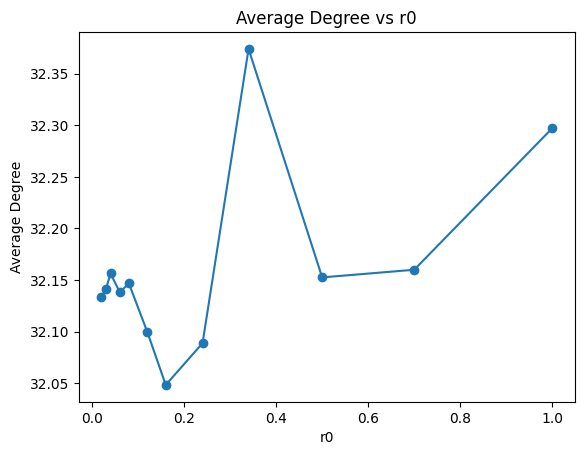

In [ ]:
avg_degs = [results[r0][PropertyEnum.AVERAGE_DEGREE] for r0 in r0s]

fig = plt.figure()

plt.plot(r0s, avg_degs, marker="o")
plt.title("Average Degree vs r0")
plt.xlabel("r0")
plt.ylabel("Average Degree")

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "average_degree_vs_r0.png", bbox_inches="tight")
plt.show()

### Degree Distribution

Individual plot example for a distribution property (degree distribution):

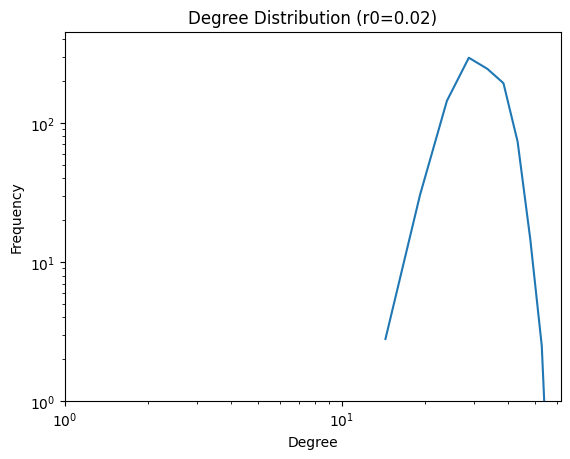

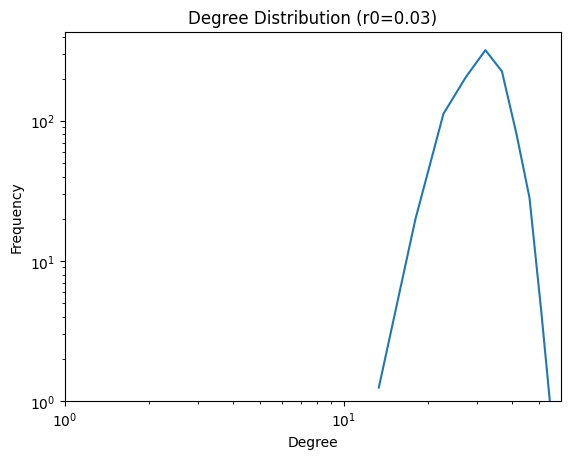

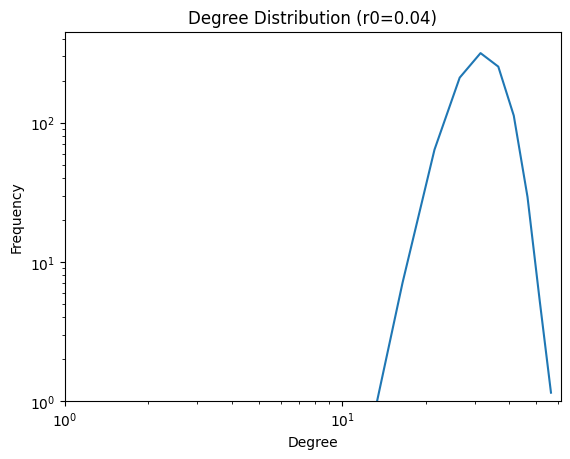

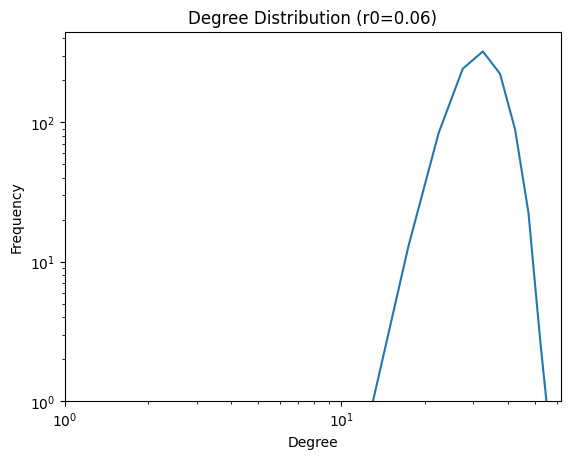

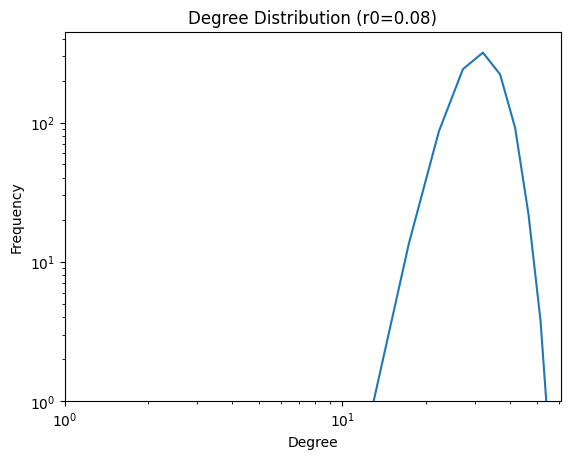

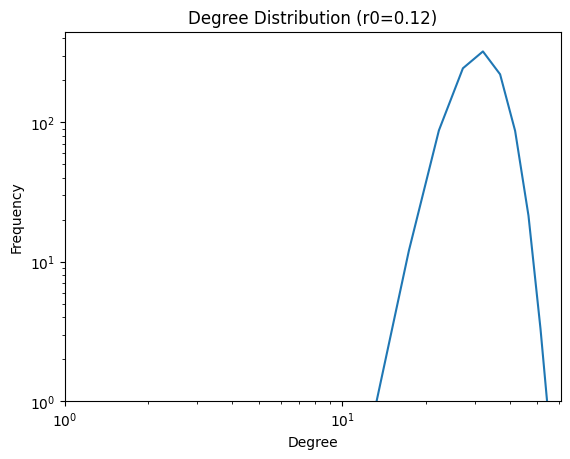

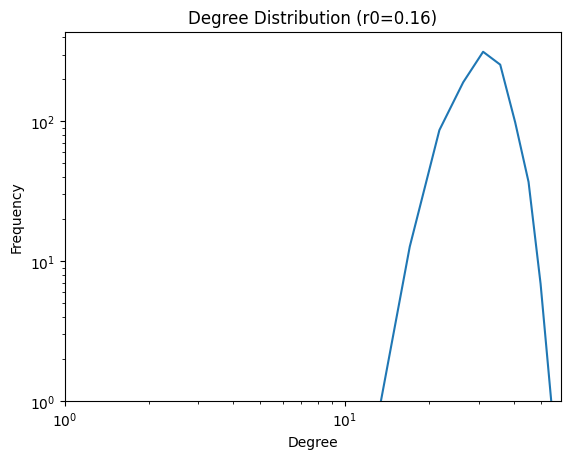

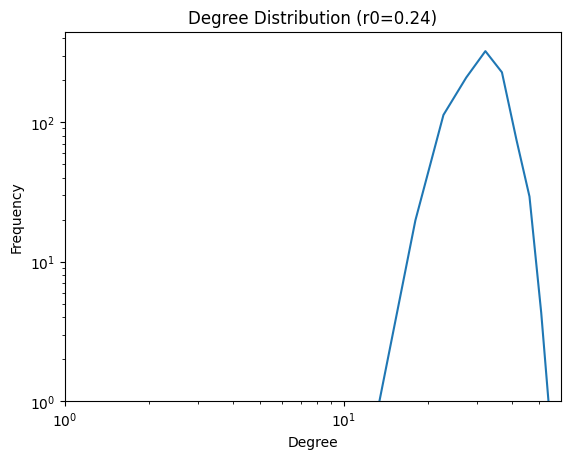

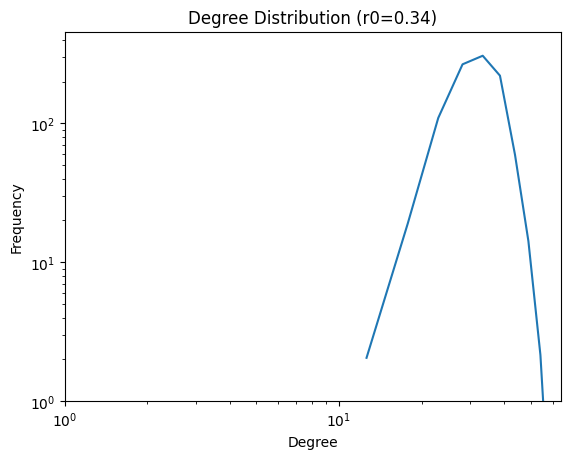

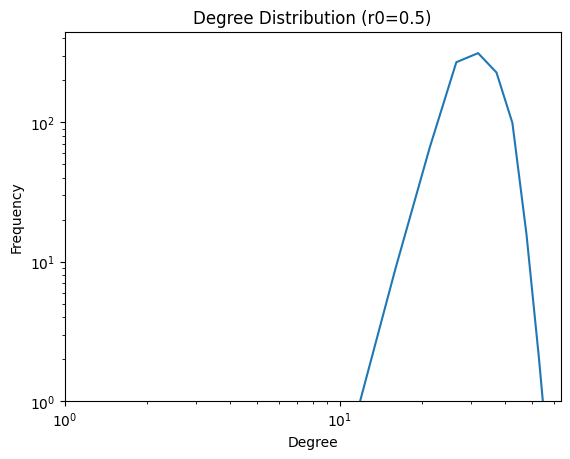

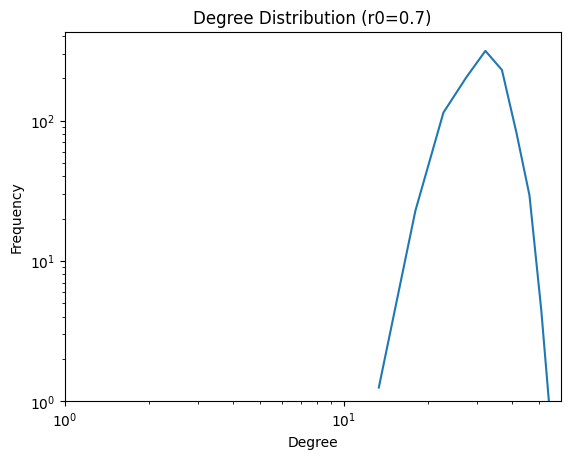

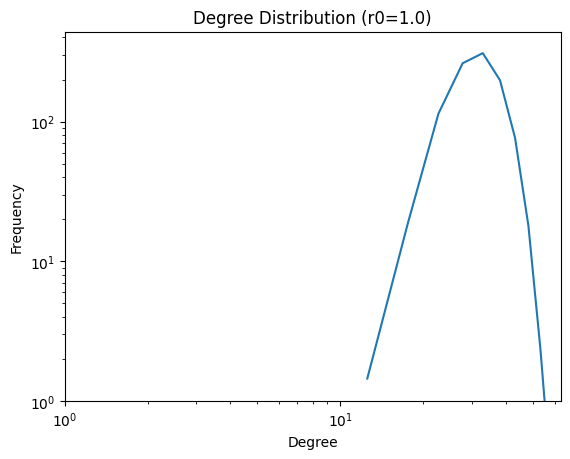

In [ ]:
for r0 in r0s:
    deg_dist = results[r0][PropertyEnum.DEGREE_DISTRIBUTION]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1]

    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig = plt.figure()

    plt.plot(bin_mids, freqs)
    plt.title(f"Degree Distribution (r0={r0})")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])

    # Save in "plots" folder of the individual run
    plt.savefig(paths["batch_dir"] / f"r0_{r0}" / "plots" / f"degree_distribution_r0_{r0}.png", bbox_inches="tight")
    plt.show()

Aggregate plot example for a distribution property (degree distribution):

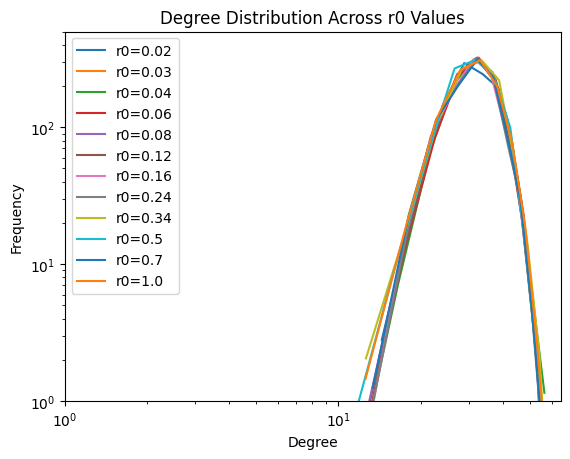

In [ ]:
fig = plt.figure()

for r0 in r0s:
    deg_dist = results[r0][PropertyEnum.DEGREE_DISTRIBUTION]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1]

    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_mids, freqs, label=f"r0={r0}")

plt.title("Degree Distribution Across r0 Values")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])
plt.legend()

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "degree_distribution_by_r0.png", bbox_inches="tight")
plt.show()

### Degree Distribution Per Layer

In [ ]:
layer_sizes = {
    'l1': 1000,
    'l2': 1500,
    'l3': 2000,
    'l4': 2500,
    'l5': 3000,
    'l6': 3500
}

r0 0.02
deg_dists_layers 6


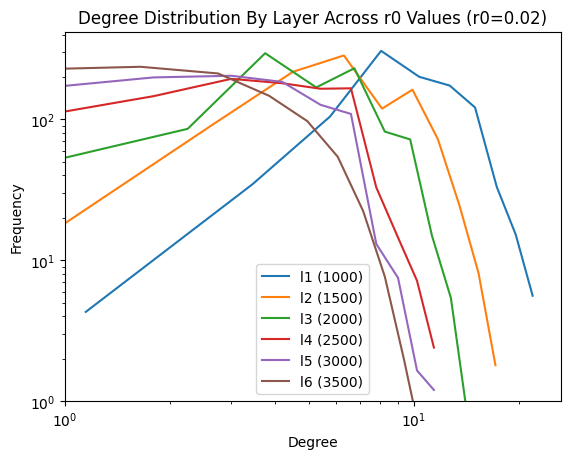

r0 0.03
deg_dists_layers 6


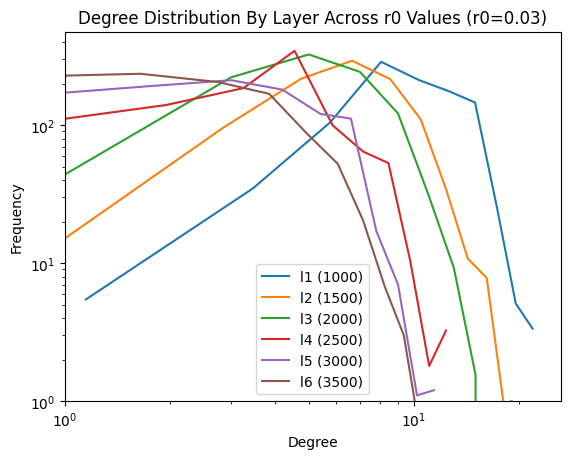

r0 0.04
deg_dists_layers 6


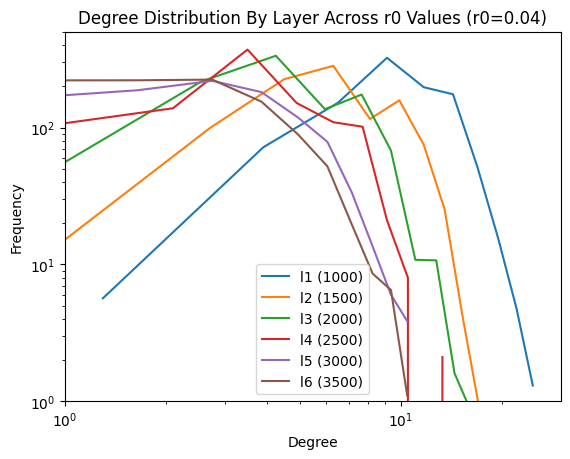

r0 0.06
deg_dists_layers 6


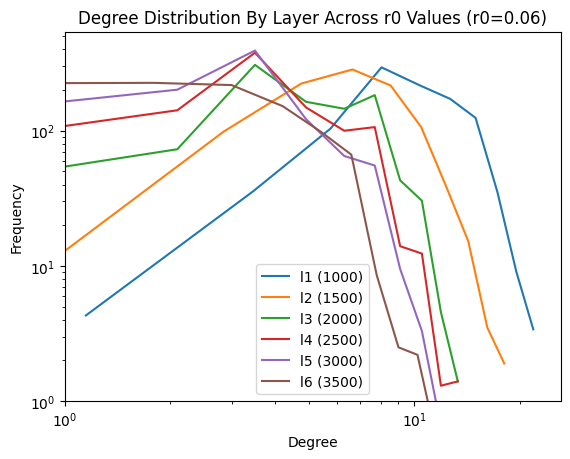

r0 0.08
deg_dists_layers 6


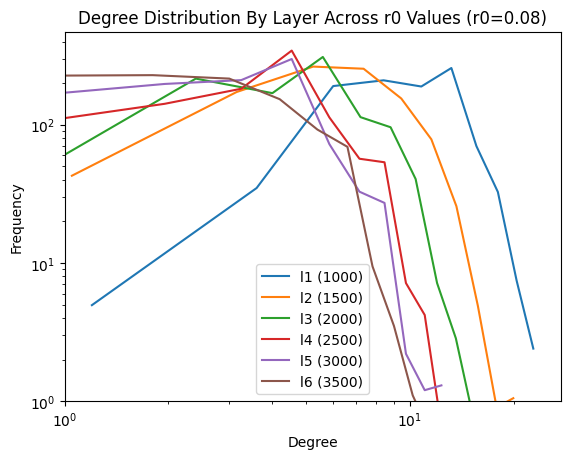

r0 0.12
deg_dists_layers 6


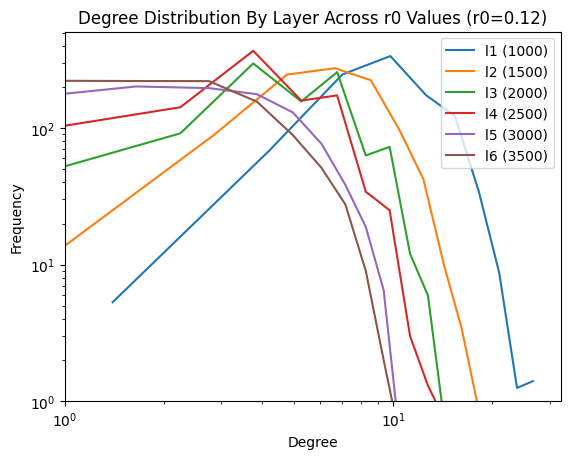

r0 0.16
deg_dists_layers 6


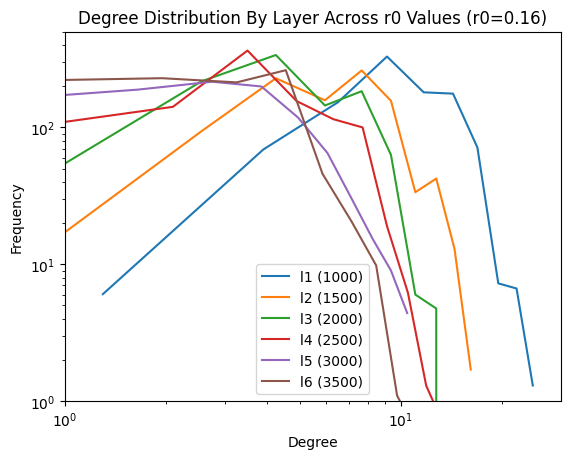

r0 0.24
deg_dists_layers 6


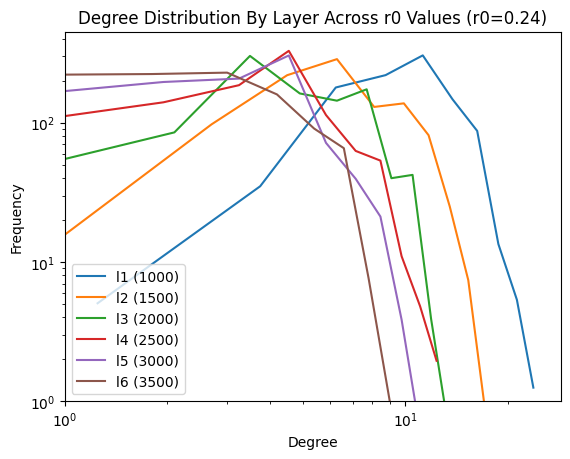

r0 0.34
deg_dists_layers 6


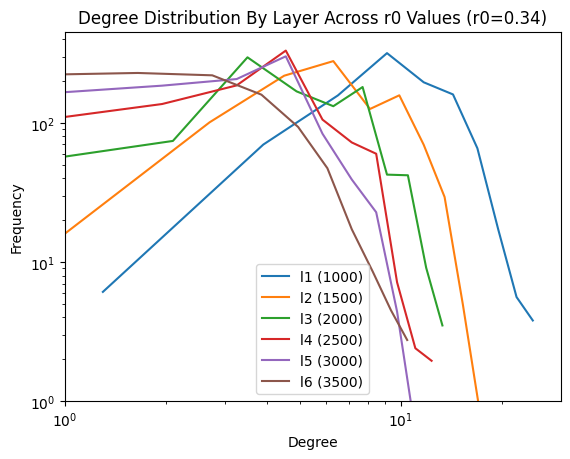

r0 0.5
deg_dists_layers 6


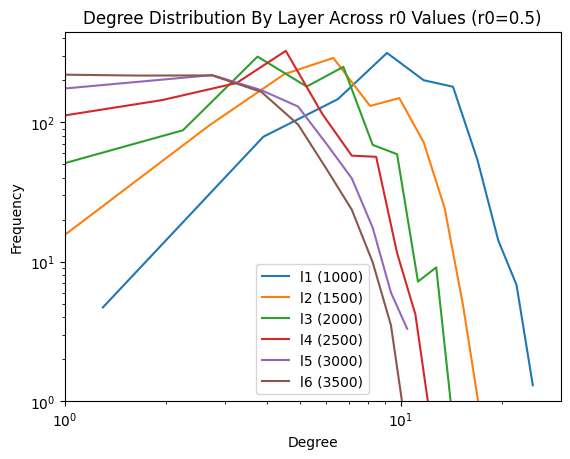

r0 0.7
deg_dists_layers 6


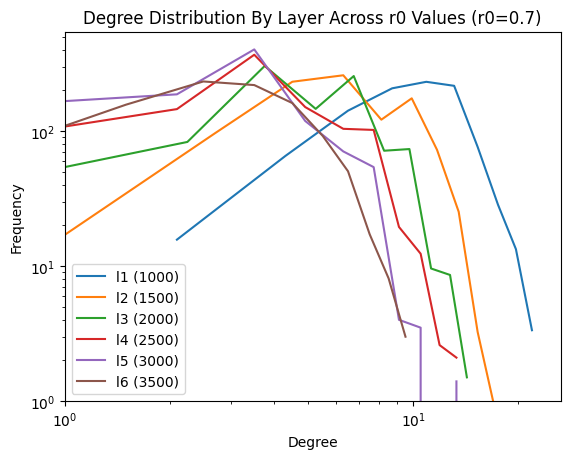

r0 1.0
deg_dists_layers 6


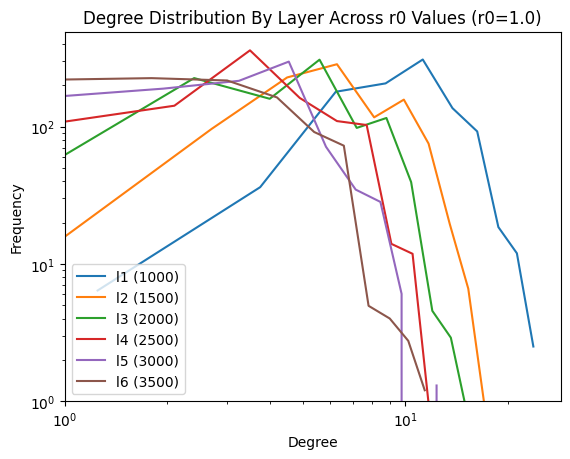

In [ ]:
#TODO: plot degree distribution per layer for every r0
for r0 in r0s:
    print("r0", r0)
    deg_dists_layers = results[r0][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]

    print("deg_dists_layers", len(deg_dists_layers))

    fig = plt.figure()

    for dist, label in zip(deg_dists_layers, cfg.network.layer_labels):
        k = dist[:, 0]
        freq = dist[:, 1]

        freqs, bin_edges = np.histogram(k, weights=freq)
        bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        plt.plot(bin_mids, freqs, label=f"{label} ({layer_sizes[label]})")

    plt.title(f"Degree Distribution By Layer Across r0 Values (r0={r0})")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])
    plt.legend()

    # Save in "plots" folder of the individual run
    plt.savefig(paths["batch_dir"] / f"r0_{r0}" / "plots" / f"degree_distribution_layer_r0_{r0}.png", bbox_inches="tight")
    plt.show()

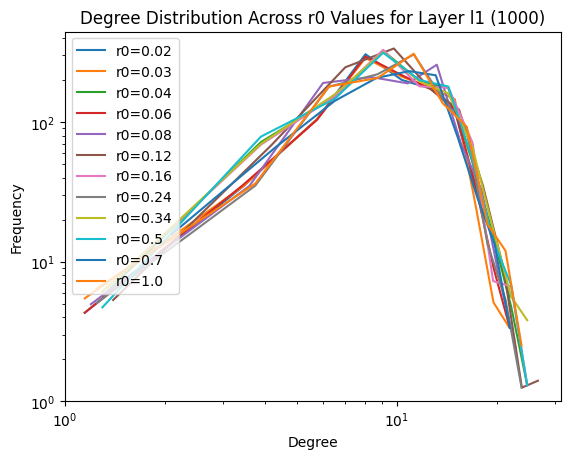

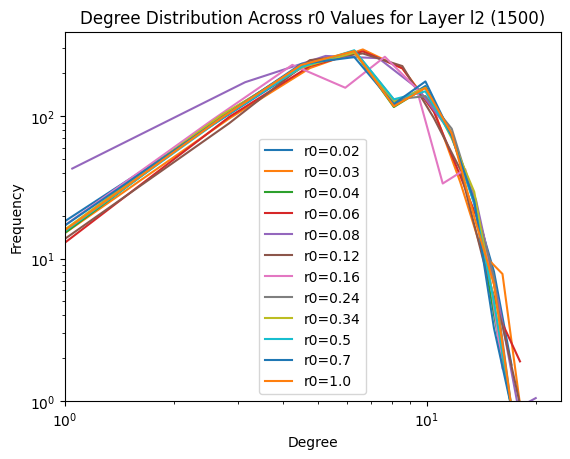

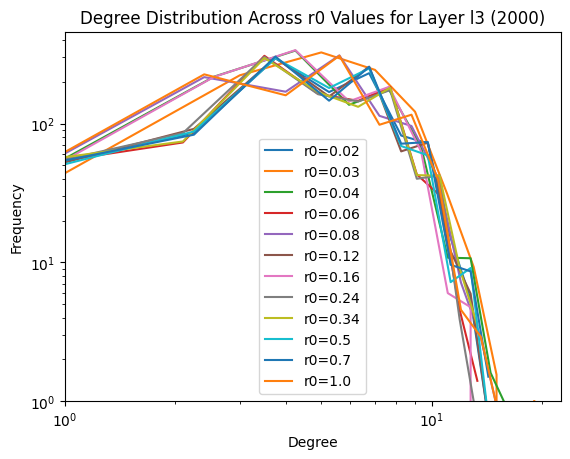

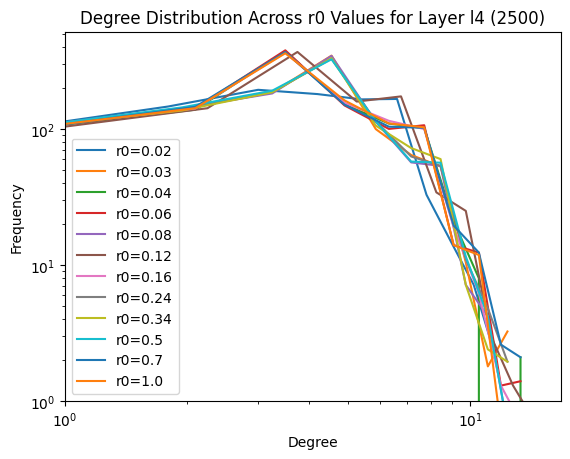

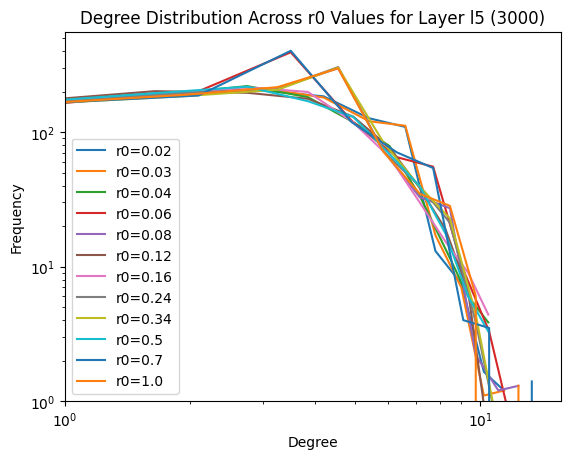

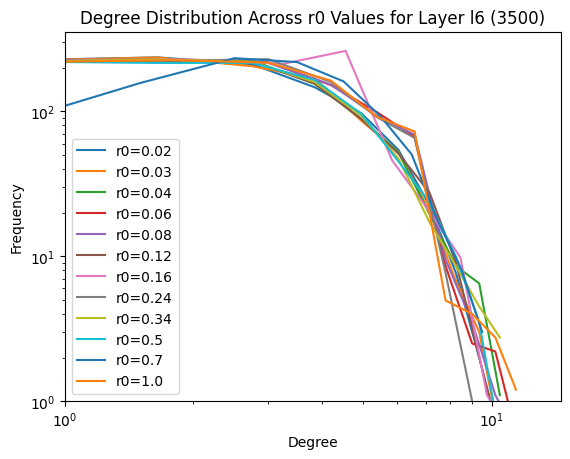

In [ ]:
# Plot one aggregate degree-distribution figure per layer,
# with one line per r0 value.

markers = ["o", "s", "^", "D", "v", "x", "*"]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    fig = plt.figure()

    i = 0

    for r0 in r0s:
        i += 1
        deg_dists_layers = results[r0][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1]

        freqs, bin_edges = np.histogram(k, weights=freq)
        bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        plt.plot(
            bin_mids,
            freqs,
            label=f"r0={r0}"
        )

    plt.title(
        f"Degree Distribution Across r0 Values "
        f"for Layer {layer_label} ({layer_sizes[layer_label]})"
    )
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])
    plt.legend()

    plt.savefig(
        paths["batch_dir"] / "plots" / f"degree_distribution_layer_{layer_label}_all_r0.png",
        bbox_inches="tight"
    )
    plt.show()

### Other Plots

In [ ]:
from msean.measurements.batch import GLOBAL_PROPERTIES, DISTRIBUTION_PROPERTIES

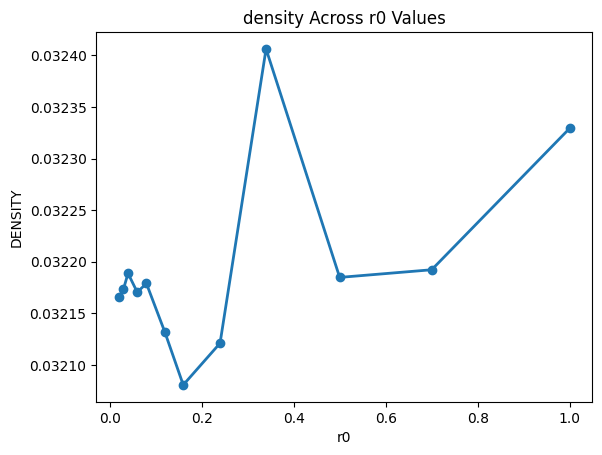

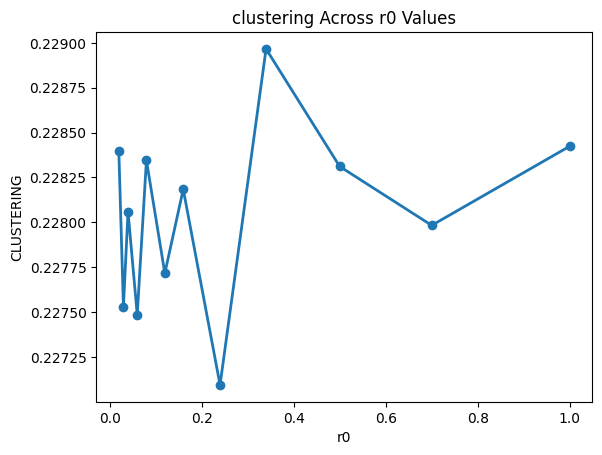

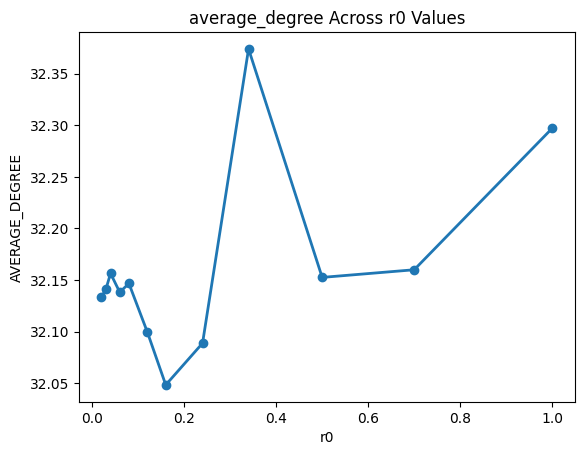

In [ ]:
for prop in GLOBAL_PROPERTIES:
    y = np.array([results[r0][prop] for r0 in r0s])

    plt.figure()
    plt.plot(r0s, y, marker="o", linewidth=2)

    plt.title(f"{prop.name.lower()} Across r0 Values")
    plt.xlabel("r0")
    plt.ylabel(prop.name)

    plt.savefig(
        paths["batch_dir"] / "plots" / f"{prop.name.lower()}_vs_r0.png",
        bbox_inches="tight",
    )
    plt.show()

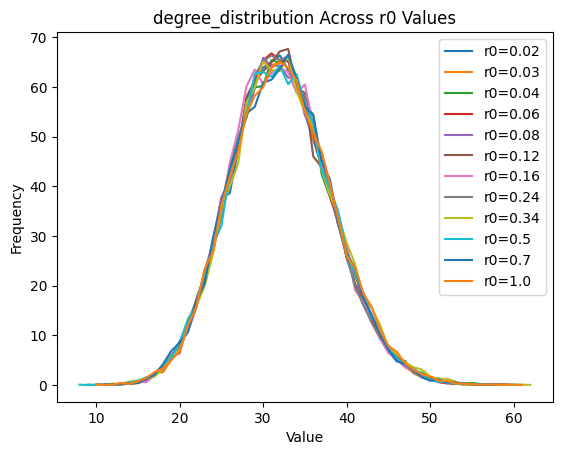

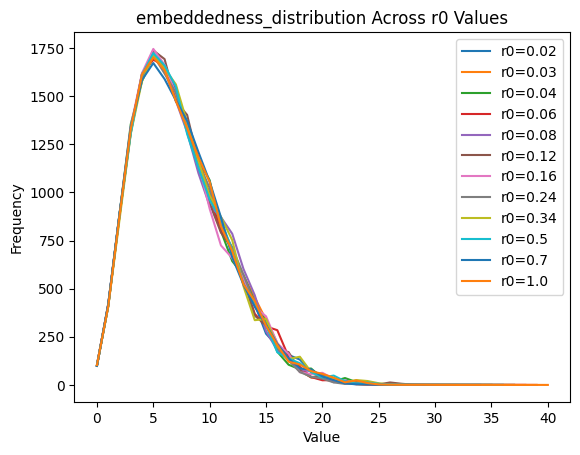

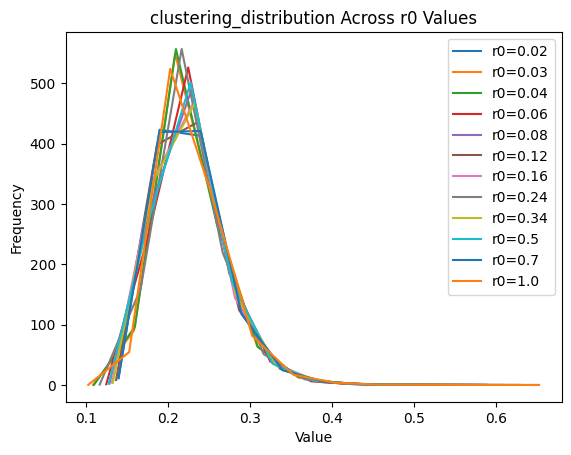

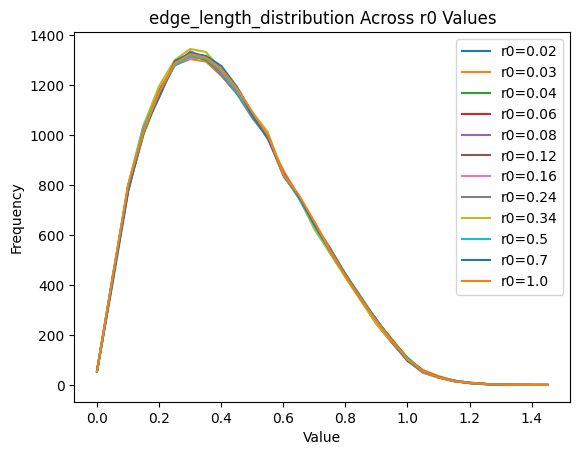

In [ ]:
for prop in DISTRIBUTION_PROPERTIES:
    if prop == PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER:
        continue
    plt.figure()

    for r0 in r0s:
        dist = results[r0][prop]

        x = dist[:, 0]
        y = dist[:, 1]

        plt.plot(
            x,
            y,
            label=f"r0={r0}",
        )

    plt.title(f"{prop.name.lower()} Across r0 Values")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()

    plt.savefig(
        paths["batch_dir"] / "plots" / f"{prop.name.lower()}_all_r0.png",
        bbox_inches="tight",
    )
    plt.show()